# Notebook for constructing age models for the Portage Lake Volcanics age model

In [34]:
using Pkg
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

plot_posterior_paths (generic function with 1 method)

## Portage Lake Volcanics

- modified from Cannon and Nicholson 2001
- The bottom of the strat is bounded by the Keweenaw fault, we assign an age of 1098 Ma based on the estimated younger side of the known beginning of the normal superchron
- The minimum age bound for the strat bottom is also the date of the Copper City Flow. 
- Greenstone Flows serves as a bound in the middle of the strat
- The top of the strat is bounded by the Nonesuch Formation which has a Re-Os age of 1078 Ma. 

In [22]:
PLV_Name = ("base1", "base2", "Copper City Flow", "Greenstone Flow", "base of Nonesuch Shale") # Et cetera
PLV_Age           = [1098,  1093.37, 1093.37, 1091.59, 1078] # Measured ages
PLV_Age_sigma     = [0,  0.53/2,  0.53/2,  0.27/2, 24/2] # Measured 1-σ uncertainties
PLV_Height        = [0,  0,   1000,      3558, 6055] # Depths below surface should be negative
PLV_Age_Sidedness = [1, -1, 0, 0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

PLV_Path = "../code_output/age_models/PLV" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
PLV_section = make_ChronAgeData(PLV_Name, PLV_Age, PLV_Age_sigma, PLV_Height, PLV_Age_Sidedness, PLV_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{5}(("base1", "base2", "Copper City Flow", "Greenstone Flow", "base of Nonesuch Shale"), [0.0, 0.0, 1000.0, 3558.0, 6055.0], [0.01, 0.01, 0.01, 0.01, 0.01], [1098.0, 1093.37, 1093.37, 1091.59, 1078.0], [0.0, 0.265, 0.265, 0.135, 12.0], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [1.0, -1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0], [#undef, #undef, #undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer, :Chronometer, :Chronometer), [NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN], "../code_output/age_models/PLV", 2, "Ma", "m", :cdf)

In [13]:
PLV_age_model_config, PLV_age_model_mdl, PLV_age_model_agedist, PLV_age_model_lldist = run_age_model(PLV_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:28
┌ Info: Burn-in: 848000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 848000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 848000, 1000, 848, 0.2), StratAgeModel([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  5960.0, 5970.0, 5980.0, 5990.0, 6000.0, 6010.0, 6020.0, 6030.0, 6040.0, 6050.0], [1095.7528009915593, 1095.7383858802582, 1095.7165399975604, 1095.7010746049352, 1095.685991501662, 1095.6559312555396, 1095.6384902242867, 1095.6145085727499, 1095.5950046792595, 1095.5745945320718  …  1080.0532818743104, 1080.0207683360939, 1079.9757583074297, 1079.930161902082, 1079.8784299671277, 1079.8479584527486, 1079.8110840496402, 1079.7691652870592, 1079.7000459254718, 1079.6422706203953], [1.3554490442689864, 1.3518559844367972, 1.353571376720322, 1.3516772362877658, 1.3543018626085879, 1.358150717890691, 1.359552482754908, 1.3640918874127343, 1.3674560979545305, 1.3659483266699135  …  3.6840893205684413, 3.681939004052553, 3.6755764749303217, 3.6529654681441057, 3.6478279909294966, 3.6453084717507642, 3.637692956101415, 3.635174388892232, 3.6310971481069307, 3.

### posterior summary age model

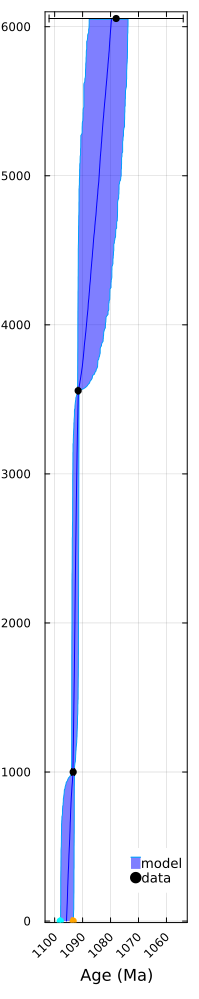

In [24]:
PLV_age_model = plot_age_model(PLV_section, PLV_age_model_mdl, save_figure=false)
plot!(ylim=(-10, 6100))
savefig(PLV_age_model, PLV_section.Path*"_AgeDepthModel.pdf")
display(PLV_age_model)

### example posterior accumulation models

  0.012114 seconds (19.00 k allocations: 15.579 MiB, 26.75% gc time)


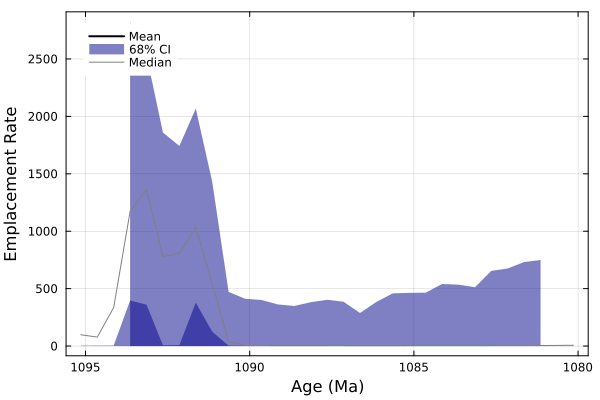

In [52]:
plot_accumulation_model(PLV_section, PLV_age_model_config, PLV_age_model_mdl, PLV_age_model_agedist, binwidth=1, binoverlap=2, save_figure=false)

### example posterior age models

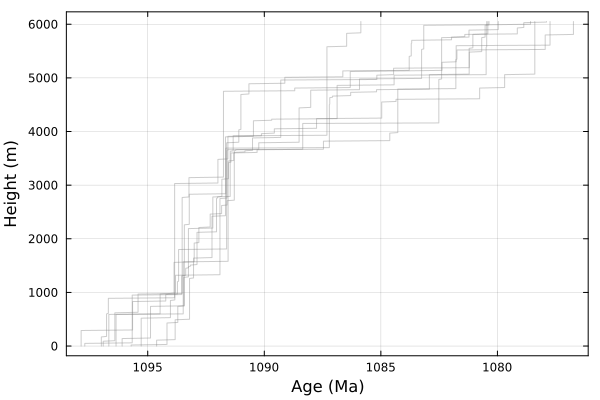

In [26]:
plot_posterior_paths(PLV_section, PLV_age_model_agedist, PLV_age_model_mdl)

## save the age models to a file

In [27]:
PLV_age_model_agedist

606×1000 Matrix{Float64}:
 1094.35  1095.7   1095.91  1097.27  …  1096.36  1094.13  1093.34  1095.28
 1094.35  1095.7   1095.91  1097.27     1096.36  1094.13  1093.34  1095.28
 1094.35  1095.7   1095.91  1097.27     1096.36  1094.13  1093.34  1095.28
 1094.35  1095.7   1095.91  1097.27     1096.36  1094.13  1093.34  1095.28
 1094.35  1095.7   1095.91  1097.27     1096.36  1094.13  1093.34  1095.28
 1094.35  1095.7   1095.91  1097.27  …  1096.36  1094.13  1093.34  1095.28
 1094.35  1095.7   1095.91  1097.27     1096.36  1094.13  1093.34  1095.28
 1094.35  1095.7   1095.91  1097.27     1096.36  1094.13  1093.34  1095.28
 1094.35  1095.7   1095.91  1097.27     1096.36  1094.13  1093.34  1095.28
 1094.35  1095.7   1095.91  1097.27     1096.36  1094.13  1093.34  1095.28
    ⋮                                ⋱                             
 1083.13  1080.78  1083.87  1083.57     1075.77  1084.01  1079.26  1083.16
 1083.13  1080.78  1083.87  1083.57     1075.77  1084.01  1079.26  1083.16
 1083.

In [28]:
# use the mdl.height as index, agedist as the data
PLV_age_models_df = DataFrame(hcat(PLV_age_model_mdl.Height, PLV_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(PLV_age_models_df, Dict(:x1 => "height"))
PLV_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1094.35,1095.7,1095.91,1097.27,1097.58,1095.13,1096.32,1095.02,1097.8,1094.75,1094.09,1095.38,1096.88,1093.35,1097.86,1096.7,1097.06,1097.1,1094.79,1094.51,1096.77,1093.26,1096.78,1095.84,1094.36,1093.16,1094.69,1096.2,1095.24,1096.74,1096.8,1095.99,1096.54,1095.12,1096.79,1096.42,1093.76,1096.58,1094.47,1095.97,1097.95,1095.92,1095.16,1095.1,1097.58,1096.23,1096.57,1095.13,1096.35,1094.52,1095.91,1097.07,1095.38,1095.75,1093.07,1095.11,1094.42,1096.02,1097.87,1097.14,1093.57,1093.54,1096.15,1095.74,1095.65,1097.61,1095.89,1093.41,1094.23,1093.71,1093.45,1096.35,1095.19,1097.62,1096.89,1096.02,1096.55,1094.2,1096.06,1094.08,1097.77,1096.29,1094.91,1097.97,1095.18,1095.1,1094.17,1095.7,1096.6,1093.39,1094.67,1095.42,1096.04,1094.25,1096.19,1097.2,1095.46,1097.09,1097.17,⋯
2,10.0,1094.35,1095.7,1095.91,1097.27,1097.58,1095.13,1096.32,1095.02,1097.8,1094.75,1094.09,1095.38,1096.88,1093.35,1097.86,1096.7,1097.06,1097.1,1094.79,1094.51,1096.77,1093.26,1096.78,1095.84,1094.36,1093.16,1094.69,1096.2,1095.24,1096.74,1096.8,1095.99,1096.54,1095.12,1096.79,1096.42,1093.76,1096.58,1094.47,1095.97,1097.95,1095.92,1095.16,1095.1,1097.58,1096.23,1096.57,1095.13,1096.35,1094.52,1095.91,1097.07,1095.38,1095.75,1093.07,1095.11,1094.42,1096.02,1097.87,1097.14,1093.57,1093.54,1096.15,1095.74,1095.65,1097.61,1095.89,1093.41,1094.23,1093.71,1093.45,1096.35,1095.19,1097.62,1096.89,1096.02,1096.55,1094.2,1096.06,1094.08,1097.77,1096.29,1094.91,1097.97,1095.18,1095.1,1094.17,1095.7,1096.6,1093.39,1094.67,1095.42,1096.04,1094.25,1096.19,1097.2,1095.46,1097.09,1097.17,⋯
3,20.0,1094.35,1095.7,1095.91,1097.27,1097.58,1095.13,1096.32,1095.02,1097.8,1094.75,1094.09,1095.38,1096.88,1093.35,1097.86,1096.7,1097.06,1097.1,1094.79,1094.51,1096.77,1093.26,1096.78,1095.84,1094.36,1093.16,1094.69,1096.2,1095.24,1096.74,1096.8,1095.99,1093.66,1095.12,1096.79,1096.42,1093.76,1096.58,1094.47,1095.97,1097.95,1095.92,1095.16,1095.1,1097.58,1096.23,1096.57,1095.13,1096.35,1094.52,1094.93,1097.07,1095.38,1095.75,1093.07,1095.11,1094.42,1096.02,1097.87,1097.14,1093.57,1093.54,1096.15,1095.74,1095.65,1097.61,1095.89,1093.41,1094.23,1093.71,1093.45,1096.35,1095.19,1097.62,1096.89,1096.02,1096.55,1094.2,1096.06,1094.08,1097.77,1096.29,1094.91,1097.97,1095.18,1094.38,1094.17,1095.7,1096.6,1093.39,1094.67,1095.42,1096.04,1094.25,1096.19,1097.2,1095.46,1097.09,1097.17,⋯
4,30.0,1094.35,1095.7,1095.91,1097.27,1097.58,1095.13,1096.32,1095.02,1097.8,1094.75,1094.09,1095.38,1096.88,1093.35,1097.86,1096.7,1097.06,1097.1,1094.79,1094.51,1096.77,1093.26,1096.78,1095.84,1094.36,1093.16,1094.69,1096.2,1095.24,1096.74,1096.8,1095.99,1093.66,1095.12,1096.79,1096.42,1093.76,1096.58,1094.47,1095.97,1097.95,1095.92,1095.16,1095.1,1097.58,1096.23,1096.57,1095.13,1096.35,1094.52,1094.93,1097.07,1095.38,1095

In [29]:
# write the DataFrame to a csv file
CSV.write(PLV_section.Path*"_posterior_ages.csv", PLV_age_models_df)

"../code_output/age_models/PLV_posterior_ages.csv"